## Display first 5 Rows

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/student_placement_prediction_dataset_2026-selected-columns.csv"
)

df.head()

,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,mock_interview_score,backlogs,placement_status
0,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,81.707722,57.707166,59.070073,72.647009,2,Not Placed
1,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,63.116715,59.197085,78.976419,61.699110,1,Not Placed
2,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,48.658753,92.104885,80.603331,87.396911,0,Placed
3,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,66.376653,83.411798,64.187246,58.401069,1,Not Placed
4,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,61.274985,88.956331,56.163678,74.489201,1,Placed


## Columns and Data Type

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (100000, 15)

Column Names:
['age', 'gender', 'cgpa', 'branch', 'college_tier', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'mock_interview_score', 'backlogs', 'placement_status']

Data Types:
age                            int64
gender                           str
cgpa                         float64
branch                           str
college_tier                     str
internships_count              int64
projects_count                 int64
certifications_count           int64
coding_skill_score           float64
aptitude_score               float64
communication_skill_score    float64
logical_reasoning_score      float64
mock_interview_score         float64
backlogs                       int64
placement_status                 str
dtype: object


## missing values

In [4]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
mock_interview_score         0
backlogs                     0
placement_status             0
dtype: int64

Duplicate Rows:
0


## Placement Distribution

In [5]:
target_counts = df["placement_status"].value_counts()

print("Placement Status Counts:")
print(target_counts)

print("\nPlacement Status Percentage:")
print(df["placement_status"].value_counts(normalize=True) * 100)

Placement Status Counts:
placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64

Placement Status Percentage:
placement_status
Placed        54.459
Not Placed    45.541
Name: proportion, dtype: float64


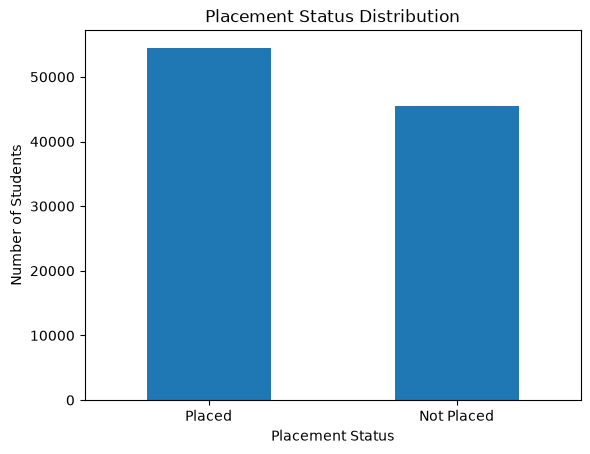

In [6]:
target_counts.plot(
    kind="bar",
    title="Placement Status Distribution"
)

plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

### CGPA statistics by placement

In [7]:
df.groupby("placement_status")["cgpa"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
placement_status,,,,
Not Placed,7.483789,7.49,4.5,10.0
Placed,7.507846,7.51,4.5,10.0


### CGPA distribution

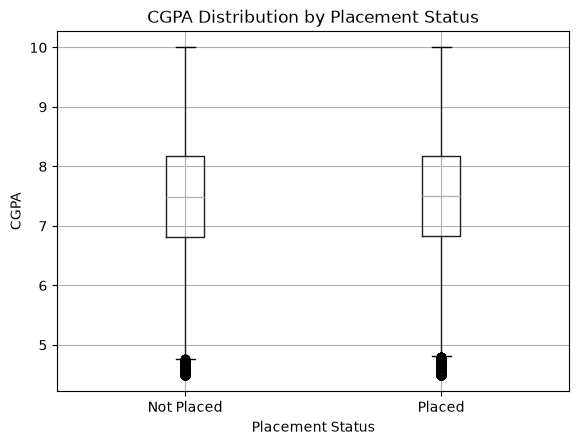

In [8]:
df.boxplot(
    column="cgpa",
    by="placement_status"
)

plt.title("CGPA Distribution by Placement Status")
plt.suptitle("")
plt.xlabel("Placement Status")
plt.ylabel("CGPA")
plt.show()

## Internships, Projects & Certifications


### Internships

In [9]:
df.groupby("placement_status")["internships_count"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
placement_status,,,,
Not Placed,1.417163,1.0,0,8
Placed,1.573367,1.0,0,8


In [10]:
df.groupby("internships_count")["placement_status"].value_counts(normalize=True).unstack() * 100

placement_status,Not Placed,Placed
internships_count,,
0,49.682475,50.317525
1,46.297621,53.702379
2,44.600247,55.399753
3,42.048796,57.951204
4,40.055782,59.944218
5,34.631148,65.368852
6,26.744186,73.255814
7,27.027027,72.972973
8,27.272727,72.727273


### Projects

In [11]:
df.groupby("placement_status")["projects_count"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
placement_status,,,,
Not Placed,2.886410,3.0,0,12
Placed,3.098404,3.0,0,13


In [12]:
df.groupby("projects_count")["placement_status"].value_counts(normalize=True).unstack() * 100

placement_status,Not Placed,Placed
projects_count,,
0,50.909458,49.090542
1,48.760054,51.239946
2,47.212645,52.787355
3,45.697131,54.302869
4,44.192517,55.807483
5,41.419126,58.580874
6,40.794893,59.205107
7,40.097475,59.902525
8,34.451613,65.548387


### Certifications

In [13]:
df.groupby("placement_status")["certifications_count"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
placement_status,,,,
Not Placed,2.011045,2.0,0,10
Placed,2.000220,2.0,0,11


In [14]:
df.groupby("certifications_count")["placement_status"].value_counts(normalize=True).unstack() * 100

placement_status,Not Placed,Placed
certifications_count,,
0,44.974370,55.025630
1,45.426100,54.573900
2,45.830845,54.169155
3,45.539751,54.460249
4,45.643793,54.356207
5,45.718901,54.281099
6,47.155812,52.844188
7,45.639535,54.360465
8,35.616438,64.383562


## Skill Analysis

### Coding Skill

In [15]:
df.groupby("placement_status")["coding_skill_score"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
placement_status,,,,
Not Placed,69.009449,69.149666,20.0,100.0
Placed,70.507598,70.732405,20.0,100.0


In [16]:
df.groupby("placement_status")["coding_skill_score"].describe()

,count,mean,std,min,25%,50%,75%,max
placement_status,,,,,,,,
Not Placed,45541.0,69.009449,14.742008,20.0,58.986744,69.149666,79.162010,100.0
Placed,54459.0,70.507598,14.620091,20.0,60.530369,70.732405,80.759221,100.0


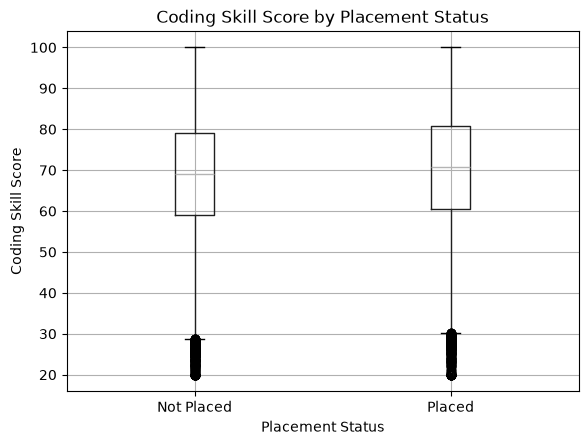

In [17]:
df.boxplot(
    column="coding_skill_score",
    by="placement_status"
)

plt.title("Coding Skill Score by Placement Status")
plt.suptitle("")
plt.xlabel("Placement Status")
plt.ylabel("Coding Skill Score")
plt.show()

### aptitude_score

In [18]:
df.groupby("placement_status")["aptitude_score"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
placement_status,,,,
Not Placed,64.473703,64.416237,20.0,100.0
Placed,65.418276,65.469800,20.0,100.0


In [19]:
df.groupby("placement_status")["aptitude_score"].describe()

,count,mean,std,min,25%,50%,75%,max
placement_status,,,,,,,,
Not Placed,45541.0,64.473703,14.835838,20.0,54.378756,64.416237,74.594539,100.0
Placed,54459.0,65.418276,14.837443,20.0,55.323007,65.469800,75.439412,100.0


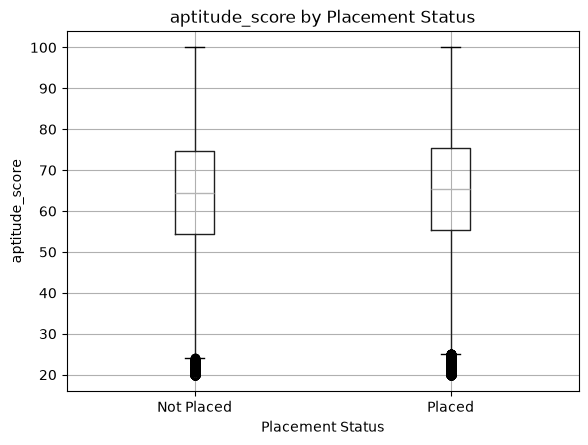

In [21]:
df.boxplot(
    column="aptitude_score",
    by="placement_status"
)

plt.title("aptitude_score by Placement Status")
plt.suptitle("")
plt.xlabel("Placement Status")
plt.ylabel("aptitude_score")
plt.show()

### communication_skill_score


In [22]:
df.groupby("placement_status")["communication_skill_score"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
placement_status,,,,
Not Placed,67.472542,67.448215,20.0,100.0
Placed,68.368999,68.440795,20.0,100.0


In [23]:
df.groupby("placement_status")["communication_skill_score"].describe()

,count,mean,std,min,25%,50%,75%,max
placement_status,,,,,,,,
Not Placed,45541.0,67.472542,13.819202,20.0,58.135824,67.448215,77.007480,100.0
Placed,54459.0,68.368999,13.856462,20.0,58.981559,68.440795,77.926139,100.0


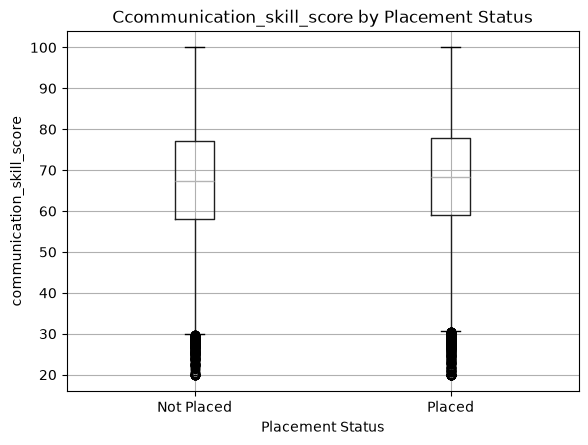

In [24]:
df.boxplot(
    column="communication_skill_score",
    by="placement_status"
)

plt.title("Ccommunication_skill_score by Placement Status")
plt.suptitle("")
plt.xlabel("Placement Status")
plt.ylabel("communication_skill_score")
plt.show()

### logical_reasoning_score


In [25]:
df.groupby("placement_status")["logical_reasoning_score"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
placement_status,,,,
Not Placed,65.342630,65.414057,20.0,100.0
Placed,66.424298,66.451542,20.0,100.0


In [26]:
df.groupby("placement_status")["logical_reasoning_score"].describe()

,count,mean,std,min,25%,50%,75%,max
placement_status,,,,,,,,
Not Placed,45541.0,65.342630,14.881248,20.0,55.280831,65.414057,75.528112,100.0
Placed,54459.0,66.424298,14.763197,20.0,56.417580,66.451542,76.610590,100.0


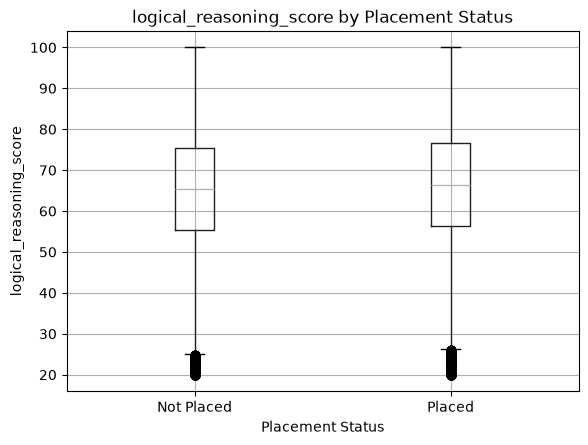

In [27]:
df.boxplot(
    column="logical_reasoning_score",
    by="placement_status"
)

plt.title("logical_reasoning_score by Placement Status")
plt.suptitle("")
plt.xlabel("Placement Status")
plt.ylabel("logical_reasoning_score")
plt.show()

### mock_interview_score

In [28]:
df.groupby("placement_status")["mock_interview_score"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
placement_status,,,,
Not Placed,69.388182,69.394943,20.0,100.0
Placed,70.492185,70.535418,20.0,100.0


In [29]:
df.groupby("placement_status")["mock_interview_score"].describe()

,count,mean,std,min,25%,50%,75%,max
placement_status,,,,,,,,
Not Placed,45541.0,69.388182,11.931625,20.0,61.336269,69.394943,77.500865,100.0
Placed,54459.0,70.492185,11.918812,20.0,62.475740,70.535418,78.599476,100.0


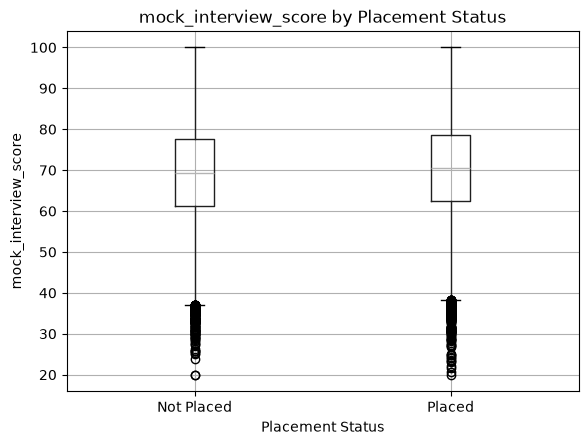

In [30]:
df.boxplot(
    column="mock_interview_score",
    by="placement_status"
)

plt.title("mock_interview_score by Placement Status")
plt.suptitle("")
plt.xlabel("Placement Status")
plt.ylabel("mock_interview_score")
plt.show()

### Gender vs Placement Status

In [31]:
gender_placement = pd.crosstab(
    df["gender"],
    df["placement_status"],
    normalize="index"
) * 100

gender_placement

placement_status,Not Placed,Placed
gender,,
Female,45.616932,54.383068
Male,45.490438,54.509562


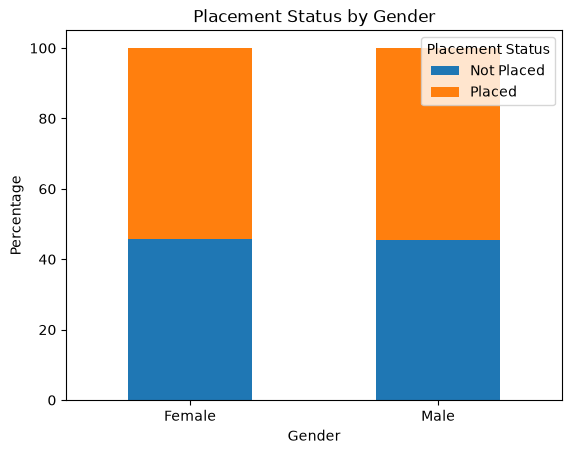

In [32]:
gender_placement.plot(
    kind="bar",
    stacked=True
)

plt.title("Placement Status by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Placement Status")
plt.show()

### Branch vs Placement Status

In [33]:
branch_placement = pd.crosstab(
    df["branch"],
    df["placement_status"],
    normalize="index"
) * 100

branch_placement

placement_status,Not Placed,Placed
branch,,
CSE,45.355850,54.644150
Civil,44.825866,55.174134
ECE,45.894822,54.105178
EEE,45.681439,54.318561
IT,45.697285,54.302715
Mechanical,45.916443,54.083557


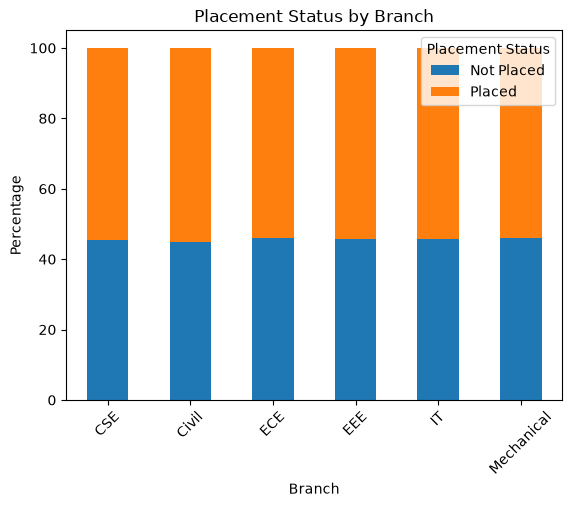

In [34]:
branch_placement.plot(
    kind="bar",
    stacked=True
)

plt.title("Placement Status by Branch")
plt.xlabel("Branch")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(title="Placement Status")
plt.show()

### College Tier vs Placement Status

In [35]:
tier_placement = pd.crosstab(
    df["college_tier"],
    df["placement_status"],
    normalize="index"
) * 100

tier_placement

placement_status,Not Placed,Placed
college_tier,,
Tier 1,45.498735,54.501265
Tier 2,45.715144,54.284856
Tier 3,45.278410,54.721590


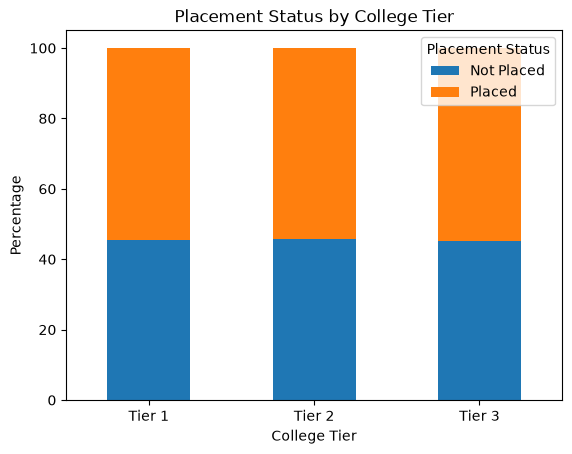

In [ ]:
tier_placement.plot(
    kind="bar",
    stacked=True
)

plt.title("Placement Status by College Tier")
plt.xlabel("College Tier")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Placement Status")
plt.show()

## Correlation Analysis

In [5]:
# Select numerical columns
numeric_columns = [
    "age",
    "cgpa",
    "internships_count",
    "projects_count",
    "certifications_count",
    "coding_skill_score",
    "aptitude_score",
    "communication_skill_score",
    "logical_reasoning_score",
    "mock_interview_score",
    "backlogs"
]

correlation = df[numeric_columns].corr()

correlation

,age,cgpa,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,mock_interview_score,backlogs
age,1.000000,0.004160,0.002791,-0.002062,-0.000056,0.000573,-0.000839,-0.000353,0.001009,-0.004293,-0.001162
cgpa,0.004160,1.000000,0.004149,0.004069,-0.001269,0.004129,-0.003143,0.004439,-0.002373,-0.000787,-0.001086
internships_count,0.002791,0.004149,1.000000,0.000625,-0.002689,-0.002755,0.000561,-0.001777,-0.000275,0.004463,0.003531
projects_count,-0.002062,0.004069,0.000625,1.000000,0.001765,-0.003686,-0.000822,-0.002146,-0.005138,-0.003240,0.001658
certifications_count,-0.000056,-0.001269,-0.002689,0.001765,1.000000,-0.001757,-0.000309,0.001655,-0.000596,0.003777,0.002230
coding_skill_score,0.000573,0.004129,-0.002755,-0.003686,-0.001757,1.000000,-0.000591,-0.000151,0.001806,-0.005713,-0.003305
aptitude_score,-0.000839,-0.003143,0.000561,-0.000822,-0.000309,-0.000591,1.000000,-0.002720,0.000469,-0.003278,0.001982
communication_skill_score,-0.000353,0.004439,-0.001777,-0.002146,0.001655,-0.000151,-0.002720,1.000000,0.003984,0.000714,-0.000546
logical_reasoning_score,0.001009,-0.002373,-0.000275,-0.005138,-0.000596,0.001806,0.000469,0.003984,1.000000,0.004122,-0.000679
mock_interview_score,-0.004293,-0.000787,0.004463,-0.003240,0.003777,-0.005713,-0.003278,0.000714,0.004122,1.000000,-0.003349


In [6]:
# Correlation with placement status

df["placement_status_numeric"] = (
    df["placement_status"]
    .map({"Not Placed": 0, "Placed": 1})
)

target_correlation = (
    df[numeric_columns + ["placement_status_numeric"]]
    .corr()["placement_status_numeric"]
    .sort_values(ascending=False)
)

target_correlation

placement_status_numeric     1.000000
internships_count            0.063489
projects_count               0.060964
coding_skill_score           0.050773
mock_interview_score         0.046058
logical_reasoning_score      0.036332
communication_skill_score    0.032242
aptitude_score               0.031690
cgpa                         0.012067
age                          0.000858
certifications_count        -0.003806
backlogs                    -0.082404
Name: placement_status_numeric, dtype: float64

In [7]:
# Check placement status distribution
print("Placement Status Distribution:")
print(df["placement_status"].value_counts())

print("\nPlacement Status Percentage:")
print(df["placement_status"].value_counts(normalize=True) * 100)

Placement Status Distribution:
placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64

Placement Status Percentage:
placement_status
Placed        54.459
Not Placed    45.541
Name: proportion, dtype: float64


In [8]:
# Compare average feature values between placed and not placed students

comparison = df.groupby("placement_status")[numeric_columns].mean().T

comparison

placement_status,Not Placed,Placed
age,21.003865,21.007308
cgpa,7.483789,7.507846
internships_count,1.417163,1.573367
projects_count,2.886410,3.098404
certifications_count,2.011045,2.000220
coding_skill_score,69.009449,70.507598
aptitude_score,64.473703,65.418276
communication_skill_score,67.472542,68.368999
logical_reasoning_score,65.342630,66.424298
mock_interview_score,69.388182,70.492185


In [9]:
# Difference between placed and not placed students

difference = (
    df.groupby("placement_status")[numeric_columns]
    .mean()
    .T
)

difference["difference"] = (
    difference.iloc[:, 1] - difference.iloc[:, 0]
)

difference.sort_values("difference", ascending=False)

placement_status,Not Placed,Placed,difference
coding_skill_score,69.009449,70.507598,1.498149
mock_interview_score,69.388182,70.492185,1.104004
logical_reasoning_score,65.342630,66.424298,1.081668
aptitude_score,64.473703,65.418276,0.944573
communication_skill_score,67.472542,68.368999,0.896457
projects_count,2.886410,3.098404,0.211994
internships_count,1.417163,1.573367,0.156205
cgpa,7.483789,7.507846,0.024058
age,21.003865,21.007308,0.003444
certifications_count,2.011045,2.000220,-0.010825


In [10]:
# Check whether placement status is actually connected to the features

for column in numeric_columns:
    print(f"\n{column}")
    print(df.groupby("placement_status")[column].describe())


age
                    count       mean       std   min   25%   50%   75%   max
placement_status                                                            
Not Placed        45541.0  21.003865  2.002202  18.0  19.0  21.0  23.0  24.0
Placed            54459.0  21.007308  1.997368  18.0  19.0  21.0  23.0  24.0

cgpa
                    count      mean       std  min   25%   50%   75%   max
placement_status                                                          
Not Placed        45541.0  7.483789  0.993122  4.5  6.81  7.49  8.17  10.0
Placed            54459.0  7.507846  0.992469  4.5  6.83  7.51  8.18  10.0

internships_count
                    count      mean       std  min  25%  50%  75%  max
placement_status                                                      
Not Placed        45541.0  1.417163  1.182647  0.0  1.0  1.0  2.0  8.0
Placed            54459.0  1.573367  1.255416  0.0  1.0  1.0  2.0  8.0

projects_count
                    count      mean       std  min  25%  50%  

## Baseline ML experiment using Logistic Regression

In [11]:
# Baseline ML experiment

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Features and target
X = df.drop(columns=["placement_status"])
y = df["placement_status"].map({
    "Not Placed": 0,
    "Placed": 1
})

# Identify columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

# Model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Train
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation
print("\n===== Logistic Regression Results =====")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Placed", "Placed"]
))

C:\Users\gowth\AppData\Local\Temp\ipykernel_19644\4026894553.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()


Numeric features:
['age', 'cgpa', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'mock_interview_score', 'backlogs', 'placement_status_numeric']

Categorical features:
['gender', 'branch', 'college_tier']

===== Logistic Regression Results =====
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0

Classification Report:
              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00      9108
      Placed       1.00      1.00      1.00     10892

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



### Check categorical features against placement status

In [12]:
for column in categorical_features:
    print(f"\n===== {column} =====")
    print(pd.crosstab(
        df[column],
        df["placement_status"],
        normalize="index"
    ).round(4))


===== gender =====
placement_status  Not Placed  Placed
gender                              
Female                0.4562  0.5438
Male                  0.4549  0.5451

===== branch =====
placement_status  Not Placed  Placed
branch                              
CSE                   0.4536  0.5464
Civil                 0.4483  0.5517
ECE                   0.4589  0.5411
EEE                   0.4568  0.5432
IT                    0.4570  0.5430
Mechanical            0.4592  0.5408

===== college_tier =====
placement_status  Not Placed  Placed
college_tier                        
Tier 1                0.4550  0.5450
Tier 2                0.4572  0.5428
Tier 3                0.4528  0.5472


### Measure how strongly each individual feature separates placement status

In [13]:
# Measure how strongly each individual feature separates placement status

from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

print("Feature-level analysis:\n")

for column in numeric_features:
    auc = roc_auc_score(
        y,
        df[column]
    )
    
    # AUC below 0.5 can simply mean the relationship is reversed,
    # so use the distance from 0.5.
    strength = max(auc, 1 - auc)
    
    print(f"{column:30s} AUC = {auc:.4f} | strength = {strength:.4f}")

Feature-level analysis:

age                            AUC = 0.5005 | strength = 0.5005
cgpa                           AUC = 0.5064 | strength = 0.5064
internships_count              AUC = 0.5334 | strength = 0.5334
projects_count                 AUC = 0.5330 | strength = 0.5330
certifications_count           AUC = 0.4977 | strength = 0.5023
coding_skill_score             AUC = 0.5291 | strength = 0.5291
aptitude_score                 AUC = 0.5182 | strength = 0.5182
communication_skill_score      AUC = 0.5187 | strength = 0.5187
logical_reasoning_score        AUC = 0.5206 | strength = 0.5206
mock_interview_score           AUC = 0.5263 | strength = 0.5263
backlogs                       AUC = 0.4614 | strength = 0.5386
placement_status_numeric       AUC = 1.0000 | strength = 1.0000


### Check whether placement status may have been generated

In [14]:
# Check whether placement status may have been generated
# from a simple threshold/rule.

print("Numeric feature ranges by placement status:\n")

for column in numeric_features:
    print(f"\n{column}")
    print(
        df.groupby("placement_status")[column]
        .agg(["min", "max", "mean", "std"])
        .round(3)
    )

Numeric feature ranges by placement status:


age
                  min  max    mean    std
placement_status                         
Not Placed         18   24  21.004  2.002
Placed             18   24  21.007  1.997

cgpa
                  min   max   mean    std
placement_status                         
Not Placed        4.5  10.0  7.484  0.993
Placed            4.5  10.0  7.508  0.992

internships_count
                  min  max   mean    std
placement_status                        
Not Placed          0    8  1.417  1.183
Placed              0    8  1.573  1.255

projects_count
                  min  max   mean    std
placement_status                        
Not Placed          0   12  2.886  1.687
Placed              0   13  3.098  1.762

certifications_count
                  min  max   mean    std
placement_status                        
Not Placed          0   10  2.011  1.416
Placed              0   11  2.000  1.417

coding_skill_score
                   min    max    mean  

### Inspect Logistic Regression coefficients

In [15]:
# Inspect Logistic Regression coefficients

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]

coef_df = (
    pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients
    })
    .sort_values("coefficient", key=abs, ascending=False)
)

coef_df.head(20)

,feature,coefficient
11,num__placement_status_numeric,8.691598
13,cat__gender_Male,0.193503
12,cat__gender_Female,0.182719
21,cat__college_tier_Tier 2,0.134872
22,cat__college_tier_Tier 3,0.127809
20,cat__college_tier_Tier 1,0.113541
14,cat__branch_CSE,0.082856
18,cat__branch_IT,0.066919
15,cat__branch_Civil,0.058920
10,num__backlogs,-0.058848
